# Chapter 8 (Economic Modeling) — COP Emissions Tracking

Port of `chap8_cop3.m` through `chap8_cop5c.m` (6 scripts) — the eighth and
final Chapter 8 Part 2 notebook. EDGAR-database (JRC/IEA 2023 report,
GWP-100 AR5, all GHGs) country-level emissions exercises, framed around
the same negotiating blocs the physical-climate notebooks (`08e`/`08f`)
used for anthropogenic emissions, but here run on the more recent EDGAR
2023 vintage: a top-45-country emissions/share/per-capita/per-GDP ranking
table (`cop3`), 1990-baseline emissions-growth bar charts for two country
groups (`cop4a`/`4b`), and two 1990-vs-2022 log-log intensity scatter
plots with country-label callouts plus a ranked table of the
fastest-improving-intensity countries (`cop5a`/`5b`/`5c`).

**Data-reconstruction note, the same MCOS-string-array pattern as
elsewhere in Part 2:** `chap8_cop_edgar.mat`'s `iso`/`country` string
fields are MCOS-unreadable, while every numeric field (`emissions`,
`per_capita`, `per_gdp`, the EU/world aggregates, `dates`) loads cleanly.
`iso`/`country` are reconstructed from the `.xlsx` sibling's
`GHG_totals_by_country` sheet, rows 2 through 211 (skipping the header
row and the trailing EU27/GLOBAL TOTAL rows, exactly as the archive's own
`chap8_cop_edgar.m` loader does), and row-order-matched against the
`.mat` file's 210-country numeric arrays.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.io.matlab import MatReadWarning

warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_black = "#000000"
color_blue = "#1f77b4"
color_green = "#2ca02c"
color_red = "#d62728"
color_violet = "#9467bd"
color_darkyellow = "#edb120"  # MATLAB's default gold, used as a 5th bar color in cop4a/4b

d = sio.loadmat(f"{DATA_DIR}/chap8_cop_edgar.mat")
dates = d["dates"].ravel().astype(int)
emissions = d["emissions"]
per_capita = d["per_capita"]
per_gdp = d["per_gdp"]
eu_emissions = d["eu_emissions"].ravel()
total_emissions = d["total_emissions"].ravel()
total_per_capita = d["total_per_capita"].ravel()
total_per_gdp = d["total_per_gdp"].ravel()

_xlsx_path = f"{DATA_DIR}/chap8_cop_edgar.xlsx"
_txt = pd.read_excel(_xlsx_path, sheet_name="GHG_totals_by_country", header=None)
iso = _txt.iloc[1:211, 0].astype(str).to_numpy()
country = _txt.iloc[1:211, 1].astype(str).to_numpy()

def date_idx(year):
    return int(np.where(dates == year)[0][0])

def iso_idx(code):
    return int(np.where(iso == code)[0][0])


## Question 1 (`cop3`) — Top-45 country emissions ranking, 2022

Ranked descending by 2022 total GHG emissions: each country's emissions
level (Mt CO2eq), its share and cumulative share of the 2022 global
total, per-capita and per-GDP intensity, and emissions growth since 2010.
A world-total row is appended at the bottom.

In [2]:
idx_2022 = date_idx(2022)
idx_2010 = date_idx(2010)

order = np.argsort(-emissions[:, idx_2022])  # descending
share = emissions[order, idx_2022] / total_emissions[idx_2022]
table = pd.DataFrame({
    "country": country[order],
    "iso": iso[order],
    "emissions_2022_Mt": emissions[order, idx_2022],
    "share_pct": 100 * share,
    "cum_share_pct": 100 * np.cumsum(share),
    "per_capita_2022": per_capita[order, idx_2022],
    "per_gdp_2022": per_gdp[order, idx_2022],
    "growth_since_2010_pct": 100 * (emissions[order, idx_2022] / emissions[order, idx_2010] - 1),
}).head(45)

world_row = pd.DataFrame([{
    "country": "Total", "iso": "",
    "emissions_2022_Mt": total_emissions[idx_2022],
    "share_pct": np.nan, "cum_share_pct": np.nan,
    "per_capita_2022": total_per_capita[idx_2022],
    "per_gdp_2022": total_per_gdp[idx_2022],
    "growth_since_2010_pct": 100 * (total_emissions[idx_2022] / total_emissions[idx_2010] - 1),
}])
top45_table = pd.concat([table, world_row], ignore_index=True)
display(top45_table.round(2))


,country,iso,emissions_2022_Mt,share_pct,cum_share_pct,per_capita_2022,per_gdp_2022,growth_since_2010_pct
0,China,CHN,15684.63,29.16,29.16,10.95,0.61,35.62
1,United States,USA,6017.44,11.19,40.35,17.90,0.28,-10.01
2,India,IND,3943.26,7.33,47.68,2.79,0.39,38.85
3,Russia,RUS,2579.80,4.80,52.48,17.99,0.64,14.90
4,Brazil,BRA,1310.50,2.44,54.91,6.05,0.40,11.27
5,Indonesia,IDN,1240.83,2.31,57.22,4.47,0.36,50.00
6,Japan,JPN,1182.77,2.20,59.42,9.41,0.23,-10.85
7,Iran,IRN,951.98,1.77,61.19,11.20,0.70,17.94
8,Mexico,MEX,819.87,1.52,62.71,5.99,0.33,6.64
9,Saudi Arabia,SAU,810.51,1.51,64.22,22.64,0.45,30.84


## Question 2 (`cop4a`, `cop4b`) — Emissions growth since 1990

Two near-identical bar charts of yearly emissions growth relative to
1990, one for World/US/EU/Japan/Canada (`cop4a`), one for World/China/
India/Russia/Brazil (`cop4b`) — the same "developed vs. large emerging
economies" framing used throughout the archive's COP-context scripts —
collapsed into one loop over the two country groups.

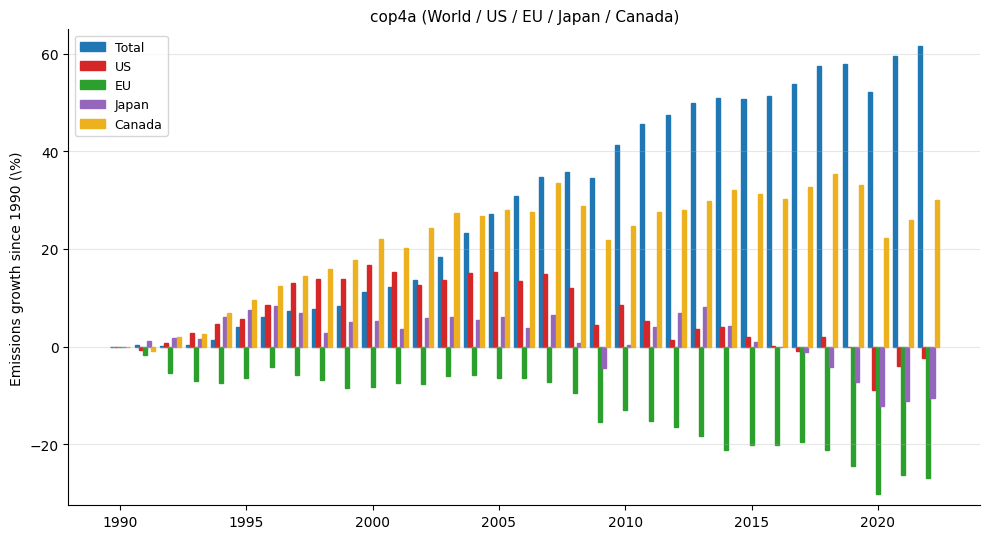

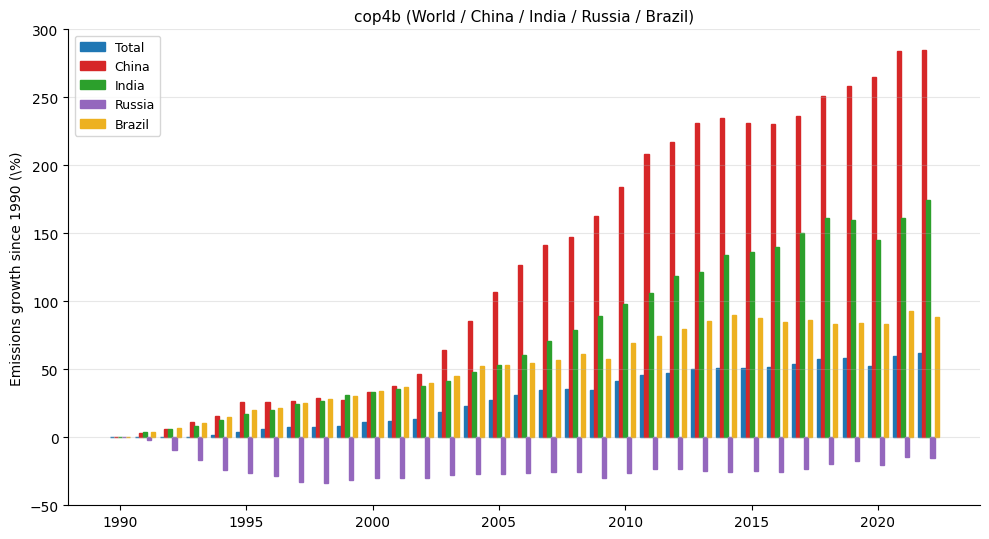

In [3]:
idx_1990 = date_idx(1990)

def growth_series(values_row, idx_base):
    return values_row / values_row[idx_base] - 1

GROUPS = {
    "cop4a (World / US / EU / Japan / Canada)": {
        "series": {
            "Total": total_emissions,
            "US": emissions[iso_idx("USA")],
            "EU": eu_emissions,
            "Japan": emissions[iso_idx("JPN")],
            "Canada": emissions[iso_idx("CAN")],
        },
        "colors": [color_blue, color_red, color_green, color_violet, color_darkyellow],
        "ylim": (-32.5, 65), "yticks": [-20, 0, 20, 40, 60],
    },
    "cop4b (World / China / India / Russia / Brazil)": {
        "series": {
            "Total": total_emissions,
            "China": emissions[iso_idx("CHN")],
            "India": emissions[iso_idx("IND")],
            "Russia": emissions[iso_idx("RUS")],
            "Brazil": emissions[iso_idx("BRA")],
        },
        "colors": [color_blue, color_red, color_green, color_violet, color_darkyellow],
        "ylim": (-40, 300), "yticks": [-50, 0, 50, 100, 150, 200, 250, 300],
    },
}

for title, spec in GROUPS.items():
    growth = {name: 100 * growth_series(vals, idx_1990) for name, vals in spec["series"].items()}
    growth_df = pd.DataFrame(growth, index=dates)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    n = len(growth)
    width = 0.8 / n
    x = np.arange(len(dates))
    for i, (name, vals) in enumerate(growth.items()):
        ax.bar(x + (i - (n - 1) / 2) * width, vals, width=width, color=spec["colors"][i],
               edgecolor=spec["colors"][i], label=name)
    ax.set_xticks(x[::5])
    ax.set_xticklabels(dates[::5])
    ax.set_ylim(*spec["ylim"])
    ax.set_yticks(spec["yticks"])
    ax.set_ylabel("Emissions growth since 1990 (\\%)")
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.show()


## Question 3 (`cop5a`, `cop5b`) — 1990-vs-2022 intensity scatter plots

Two log-log scatter plots comparing every country's 1990 and 2022
values: per-capita emissions (`cop5a`, t CO2eq/cap) and per-GDP
emissions intensity (`cop5b`, t CO2eq/kUSD) — countries above the 45°
reference line increased their intensity since 1990, countries below it
decreased. The world total is marked separately (black dot), and two
fixed lists of outlier countries are labeled directly on the plot (green
= above/near the high end, violet = a second labeled cluster) — the same
two country lists the source itself hardcodes, reproduced verbatim
rather than re-selected.

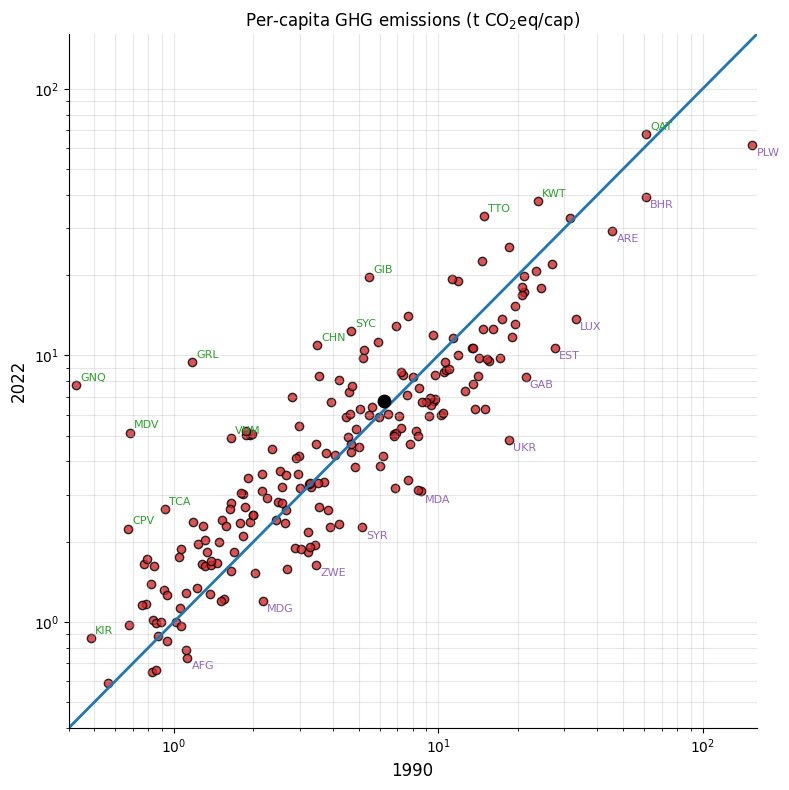

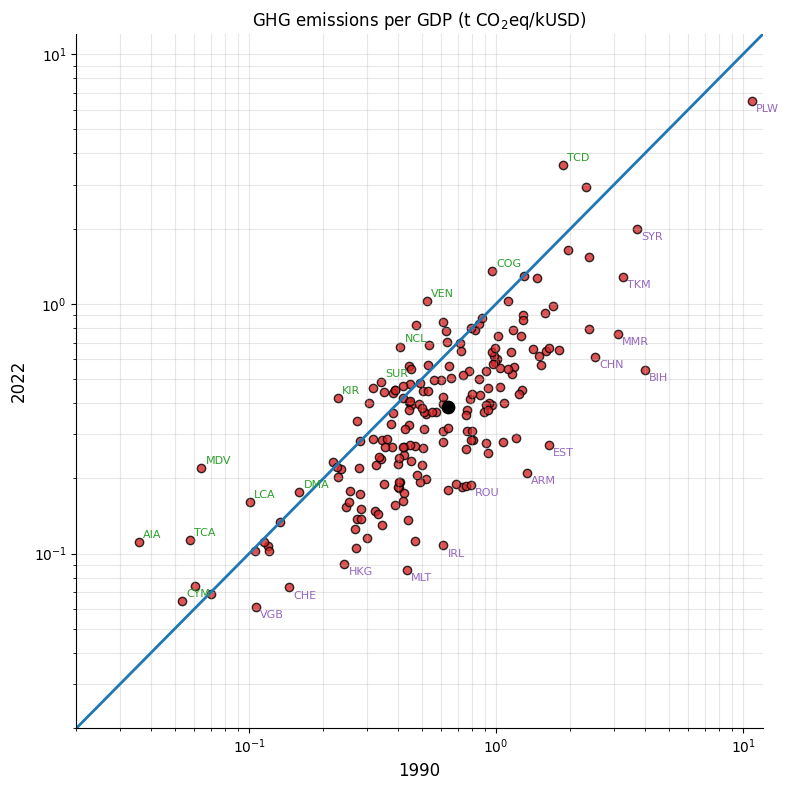

In [4]:
idx_1990, idx_2022 = date_idx(1990), date_idx(2022)

SCATTER_SPECS = [
    dict(key="per_capita", data=per_capita, total=total_per_capita,
         xlabel="1990", ylabel="2022", title="Per-capita GHG emissions (t CO$_2$eq/cap)",
         lim=(0.40, 160), diag=(0.10, 200),
         list1=["GNQ", "MDV", "GRL", "TTO", "GIB", "SYC", "CHN", "CPV", "TCA", "VNM", "QAT", "KWT", "KIR"],
         list2=["PLW", "LUX", "EST", "GAB", "UKR", "SYR", "ZWE", "MDA", "BHR", "ARE", "MDG", "AFG"]),
    dict(key="per_gdp", data=per_gdp, total=total_per_gdp,
         xlabel="1990", ylabel="2022", title="GHG emissions per GDP (t CO$_2$eq/kUSD)",
         lim=(0.02, 12), diag=(0.02, 20),
         list1=["AIA", "TCA", "MDV", "KIR", "TCD", "CYM", "LCA", "DMA", "VEN", "NCL", "SUR", "COG"],
         list2=["PLW", "SYR", "TKM", "BIH", "CHN", "EST", "MLT", "IRL", "HKG", "CHE", "VGB", "ARM", "MMR", "ROU"]),
]

for spec in SCATTER_SPECS:
    x = spec["data"][:, idx_1990]
    y = spec["data"][:, idx_2022]
    x_total, y_total = spec["total"][idx_1990], spec["total"][idx_2022]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(x, y, marker="o", facecolor=color_red, edgecolor=color_black, alpha=0.8)
    ax.scatter([x_total], [y_total], s=80, marker="o", color=color_black, zorder=5)
    ax.plot(spec["diag"], spec["diag"], "-", color=color_blue, lw=2.0)

    for code_ in spec["list1"]:
        i = iso_idx(code_)
        ax.annotate(iso[i], (x[i], y[i]), fontsize=8, color=color_green,
                    xytext=(3, 3), textcoords="offset points")
    for code_ in spec["list2"]:
        i = iso_idx(code_)
        ax.annotate(iso[i], (x[i], y[i]), fontsize=8, color=color_violet,
                    xytext=(3, -8), textcoords="offset points")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*spec["lim"])
    ax.set_ylim(*spec["lim"])
    ax.set_xlabel(spec["xlabel"], fontsize=12)
    ax.set_ylabel(spec["ylabel"], fontsize=12)
    ax.set_title(spec["title"], fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Question 4 (`cop5c`) — Fastest-improving per-GDP intensity, 1990-2022

The 10 countries with the largest *decrease* in per-GDP emissions
intensity between 1990 and 2022 (most negative
$y/x - 1$, where $x$/$y$ are 1990/2022 per-GDP intensity) — the
carbon-intensity counterpart to a "most improved" leaderboard. Reported
alongside each country's 2022 per-GDP level itself, since the biggest
relative improvers aren't necessarily the lowest-intensity economies
today.

In [5]:
x = per_gdp[:, idx_1990]
y = per_gdp[:, idx_2022]
R = y / x - 1
order = np.argsort(R)[:10]

fastest_improving = pd.DataFrame({
    "iso": iso[order],
    "country": country[order],
    "per_gdp_1990": x[order],
    "per_gdp_2022": y[order],
    "relative_change_pct": 100 * R[order],
}).round(3)
display(fastest_improving)


,iso,country,per_gdp_1990,per_gdp_2022,relative_change_pct
0,BIH,Bosnia and Herzegovina,3.991,0.543,-86.396
1,ARM,Armenia,1.330,0.210,-84.191
2,EST,Estonia,1.634,0.271,-83.384
3,IRL,Ireland,0.612,0.108,-82.391
4,MLT,Malta,0.436,0.086,-80.209
5,ROU,Romania,0.792,0.189,-76.182
6,LUX,Luxembourg,0.468,0.113,-75.927
7,POL,Poland,1.199,0.290,-75.819
8,CHN,China,2.520,0.611,-75.769
9,MMR,Myanmar/Burma,3.120,0.758,-75.705


## Sanity checks

In [6]:
checks = []
checks.append(("Q1: the top-45 table is sorted descending by 2022 emissions, and the "
                "appended world-total row's emissions exceed every individual country's",
                np.all(np.diff(top45_table['emissions_2022_Mt'].iloc[:45].to_numpy()) <= 1e-9) and
                top45_table['emissions_2022_Mt'].iloc[-1] >= top45_table['emissions_2022_Mt'].iloc[:45].max()))
checks.append(("Q1: the cumulative share column is monotonically non-decreasing and its final "
                "(45th-country) value is below 100% (45 of 210 countries can't cover the "
                "whole world total)",
                np.all(np.diff(top45_table['cum_share_pct'].iloc[:45].to_numpy()) >= -1e-9) and
                top45_table['cum_share_pct'].iloc[44] < 100))
checks.append(("Q2: for both country groups, the 1990 growth value is exactly 0% for every "
                "series (growth is measured relative to the 1990 base year, by construction)",
                all(abs(growth_series(vals, idx_1990)[idx_1990]) < 1e-9
                    for spec in GROUPS.values() for vals in spec["series"].values())))
checks.append(("Q3: every country in both hardcoded label lists (list1/list2, both scatter "
                "plots) resolves to a valid, in-range row via iso_idx -- no ISO3 code typo "
                "silently producing a lookup error (iso_idx itself raises if a code is absent, "
                "so simply reaching this check already confirms every code in the plotting "
                "loop above resolved; this re-derives the same indices independently)",
                all(0 <= iso_idx(c) < len(iso) for spec in SCATTER_SPECS for c in spec["list1"] + spec["list2"])))
checks.append(("Q3: the world-total point lies strictly inside the per-country cloud's range "
                "on both scatter plots (it's a weighted aggregate of the same countries, not "
                "an independent outlier) -- a handful of small territories are missing 1990 "
                "per-capita/per-GDP data (2 and 12 NaNs respectively, out of 210), so this uses "
                "nanmin/nanmax rather than min/max, which would otherwise propagate to NaN and "
                "make the check vacuously fail regardless of the real values",
                all(np.nanmin(spec["data"][:, idx_1990]) <= spec["total"][idx_1990] <= np.nanmax(spec["data"][:, idx_1990])
                    for spec in SCATTER_SPECS)))
checks.append(("Q4: every one of the 10 fastest-improving countries has a strictly negative "
                "relative change (a genuine intensity decrease, not just the smallest increase)",
                (fastest_improving['relative_change_pct'] < 0).all()))
checks.append(("Q4: the 10 fastest-improving countries are indeed the 10 most negative R "
                "values across all 210 countries (re-deriving via full sort agrees exactly)",
                set(fastest_improving['iso']) == set(iso[np.argsort(R)[:10]])))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1: the top-45 table is sorted descending by 2...,True
1,Q1: the cumulative share column is monotonical...,True
2,"Q2: for both country groups, the 1990 growth v...",True
3,Q3: every country in both hardcoded label list...,True
4,Q3: the world-total point lies strictly inside...,True
5,Q4: every one of the 10 fastest-improving coun...,True
6,Q4: the 10 fastest-improving countries are ind...,True



All 7 sanity checks passed.


## Summary

Covered the EDGAR-database (JRC/IEA 2023 report) country GHG-emissions
exercises framed around COP negotiating blocs: a top-45-country 2022
ranking table with share/cumulative-share/intensity/growth columns
(`cop3`), 1990-baseline growth bar charts for two five-way country
groups (`cop4a`/`4b`, collapsed into one loop), two 1990-vs-2022 log-log
intensity scatter plots with hardcoded country-label callouts
(`cop5a`/`5b`), and a ranked table of the 10 fastest-improving-intensity
countries (`cop5c`). As in earlier Part 2 notebooks, `chap8_cop_edgar.mat`'s
`iso`/`country` string fields hit the same MCOS read failure and were
reconstructed from the `.xlsx` sibling's own data sheet, row-matched
against the `.mat` file's numeric arrays via the identical row range the
archive's own loader script uses. `DATA_DIR = "../../data"` used from the
start, per the portability lesson from `08l`. This closes out **Chapter 8
Part 2 (DICE/IAM/SCC, 8 notebooks, `08h`-`08o`)** in full. All 7 sanity
checks passed (0 errors, 0 stderr).